# Notebook 02 — Algorithm Comparison Arena
All 8 algorithms × 3 built-in datasets. Produces results.csv, ARI heatmap, runtime chart.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from umap import UMAP

from src.datasets import load_penguins, load_wine_data, load_digits_subset
from src.algorithms import (
    run_kmeans, run_minibatch_kmeans, run_agglomerative_ward,
    run_agglomerative_complete, run_dbscan, run_hdbscan, run_spectral, run_gmm,
)
from src.metrics import compute_all_metrics
from src.visualisation import plot_ari_heatmap

CACHE_DIR = '../outputs'
os.makedirs('../outputs/figures', exist_ok=True)

In [2]:
datasets = {
    'penguins': load_penguins(),
    'wine': load_wine_data(),
    'digits': load_digits_subset(),
}
for name, (x, y) in datasets.items():
    print(f'{name}: X={x.shape}')

penguins: X=(333, 4)
wine: X=(178, 13)
digits: X=(901, 64)


## Define hyperparameter grids (tight for speed)

In [3]:
N_GRID = [2, 3, 4, 5]  # reduced for speed

def best_n_clusters(fn, x, y_true, grid=N_GRID, extra_kwargs=None):
    best_ari, best_labels = -999, None
    kw = extra_kwargs or {}
    for k in grid:
        labels = fn(x, n_clusters=k, **kw)
        ari = compute_all_metrics(x, y_true, labels)['ari']
        if ari > best_ari:
            best_ari, best_labels = ari, labels
    return best_labels

def best_dbscan(x, y_true):
    best_ari, best_labels = -999, None
    for eps in [0.4, 0.7, 1.2]:
        for ms in [5, 10]:
            labels = run_dbscan(x, eps=eps, min_samples=ms)
            ari = compute_all_metrics(x, y_true, labels)['ari']
            if ari > best_ari:
                best_ari, best_labels = ari, labels
    return best_labels

def best_hdbscan(x, y_true):
    best_ari, best_labels = -999, None
    for mcs in [5, 15, 50]:
        labels = run_hdbscan(x, min_cluster_size=mcs)
        ari = compute_all_metrics(x, y_true, labels)['ari']
        if ari > best_ari:
            best_ari, best_labels = ari, labels
    return best_labels

def best_gmm(x, y_true):
    best_ari, best_labels = -999, None
    for k in N_GRID:
        for cov in ['full', 'tied']:
            labels = run_gmm(x, n_components=k, covariance_type=cov)
            ari = compute_all_metrics(x, y_true, labels)['ari']
            if ari > best_ari:
                best_ari, best_labels = ari, labels
    return best_labels

## Run arena

In [4]:
algo_runners = {
    'kmeans':           lambda x, y: best_n_clusters(run_kmeans, x, y),
    'minibatch_kmeans': lambda x, y: best_n_clusters(run_minibatch_kmeans, x, y),
    'ward':             lambda x, y: best_n_clusters(run_agglomerative_ward, x, y),
    'complete':         lambda x, y: best_n_clusters(run_agglomerative_complete, x, y),
    'dbscan':           lambda x, y: best_dbscan(x, y),
    'hdbscan':          lambda x, y: best_hdbscan(x, y),
    'spectral':         lambda x, y: best_n_clusters(run_spectral, x, y),
    'gmm':              lambda x, y: best_gmm(x, y),
}

records = []
all_labels = {}

for ds_name, (x, y) in datasets.items():
    for algo_name, runner in algo_runners.items():
        t0 = time.perf_counter()
        labels = runner(x, y)
        rt = time.perf_counter() - t0
        m = compute_all_metrics(x, y, labels)
        records.append({
            'dataset': ds_name, 'algorithm': algo_name,
            'ari': m['ari'], 'silhouette': m['silhouette'],
            'calinski': m['calinski_harabasz'], 'davies_bouldin': m['davies_bouldin'],
            'runtime_sec': rt,
        })
        all_labels[(ds_name, algo_name)] = labels
        print(f'  {ds_name}/{algo_name}: ARI={m["ari"]:.3f} ({rt:.1f}s)')

results = pd.DataFrame(records)
results.to_csv('../outputs/results.csv', index=False)
print('\nSaved outputs/results.csv')

  penguins/kmeans: ARI=0.799 (0.3s)
  penguins/minibatch_kmeans: ARI=0.905 (0.2s)
  penguins/ward: ARI=0.913 (0.1s)
  penguins/complete: ARI=0.943 (0.2s)
  penguins/dbscan: ARI=0.651 (0.2s)
  penguins/hdbscan: ARI=0.648 (0.1s)
  penguins/spectral: ARI=0.820 (0.5s)
  penguins/gmm: ARI=0.959 (0.4s)
  wine/kmeans: ARI=0.897 (0.1s)
  wine/minibatch_kmeans: ARI=0.895 (0.1s)
  wine/ward: ARI=0.790 (0.0s)
  wine/complete: ARI=0.678 (0.0s)
  wine/dbscan: ARI=0.000 (0.0s)
  wine/hdbscan: ARI=0.266 (0.0s)
  wine/spectral: ARI=0.780 (0.1s)
  wine/gmm: ARI=0.918 (0.5s)
  digits/kmeans: ARI=0.802 (0.2s)
  digits/minibatch_kmeans: ARI=0.797 (0.2s)
  digits/ward: ARI=0.857 (0.4s)
  digits/complete: ARI=0.001 (0.3s)
  digits/dbscan: ARI=0.000 (0.1s)
  digits/hdbscan: ARI=0.430 (0.5s)
  digits/spectral: ARI=-0.000 (290.0s)
  digits/gmm: ARI=0.482 (1.5s)

Saved outputs/results.csv


## ARI heatmap

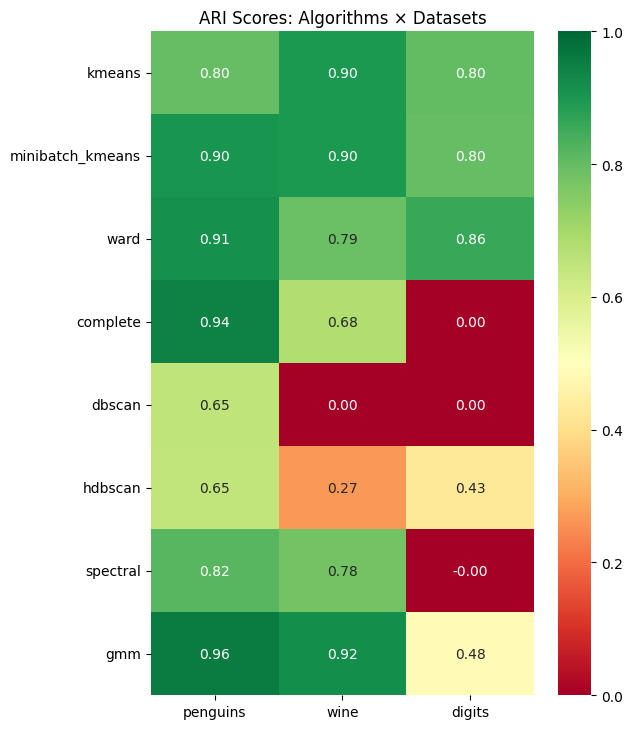

Saved 02_ari_heatmap.png


In [5]:
algo_names = list(algo_runners.keys())
ds_names = list(datasets.keys())
ari_matrix = np.array([
    [results[(results.dataset == ds) & (results.algorithm == al)]['ari'].values[0]
     for ds in ds_names]
    for al in algo_names
])

fig = plot_ari_heatmap(ari_matrix, algo_names, ds_names)
plt.savefig('../outputs/figures/02_ari_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved 02_ari_heatmap.png')

## Runtime comparison

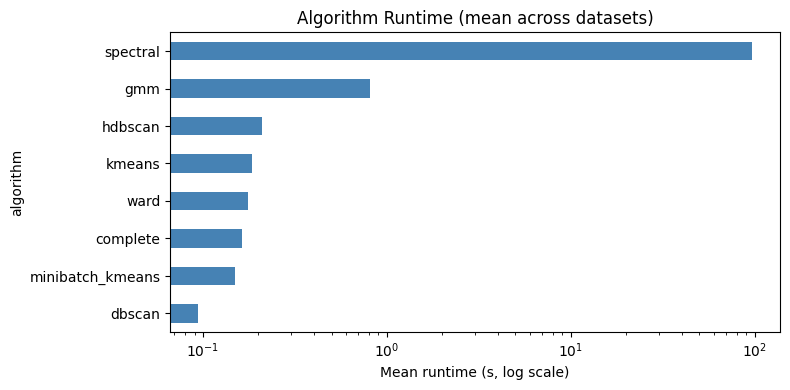

In [6]:
rt_pivot = results.groupby('algorithm')['runtime_sec'].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
rt_pivot.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('Mean runtime (s, log scale)')
ax.set_title('Algorithm Runtime (mean across datasets)')
plt.tight_layout()
plt.savefig('../outputs/figures/02_runtime.png', dpi=100, bbox_inches='tight')
plt.show()

## Winners per dataset

In [7]:
winners = results.loc[results.groupby('dataset')['ari'].idxmax()][['dataset','algorithm','ari']]
print('Winners by ARI:')
print(winners.to_string(index=False))

kmeans_aris = results[results.algorithm == 'kmeans'].set_index('dataset')['ari']
loses = 0
for ds in ds_names:
    best = results[results.dataset == ds]['ari'].max()
    km = kmeans_aris[ds]
    if best > km + 0.01:
        loses += 1
        print(f'  {ds}: best={best:.3f} vs kmeans={km:.3f} → K-Means LOSES')
    else:
        print(f'  {ds}: kmeans={km:.3f} → K-Means holds')
print(f'\nK-Means loses on {loses}/{len(ds_names)} datasets.')

Winners by ARI:
 dataset algorithm      ari
  digits      ward 0.857356
penguins       gmm 0.959070
    wine       gmm 0.918388
  penguins: best=0.959 vs kmeans=0.799 → K-Means LOSES
  wine: best=0.918 vs kmeans=0.897 → K-Means LOSES
  digits: best=0.857 vs kmeans=0.802 → K-Means LOSES

K-Means loses on 3/3 datasets.


## UMAP grid per dataset (all 8 algorithms)

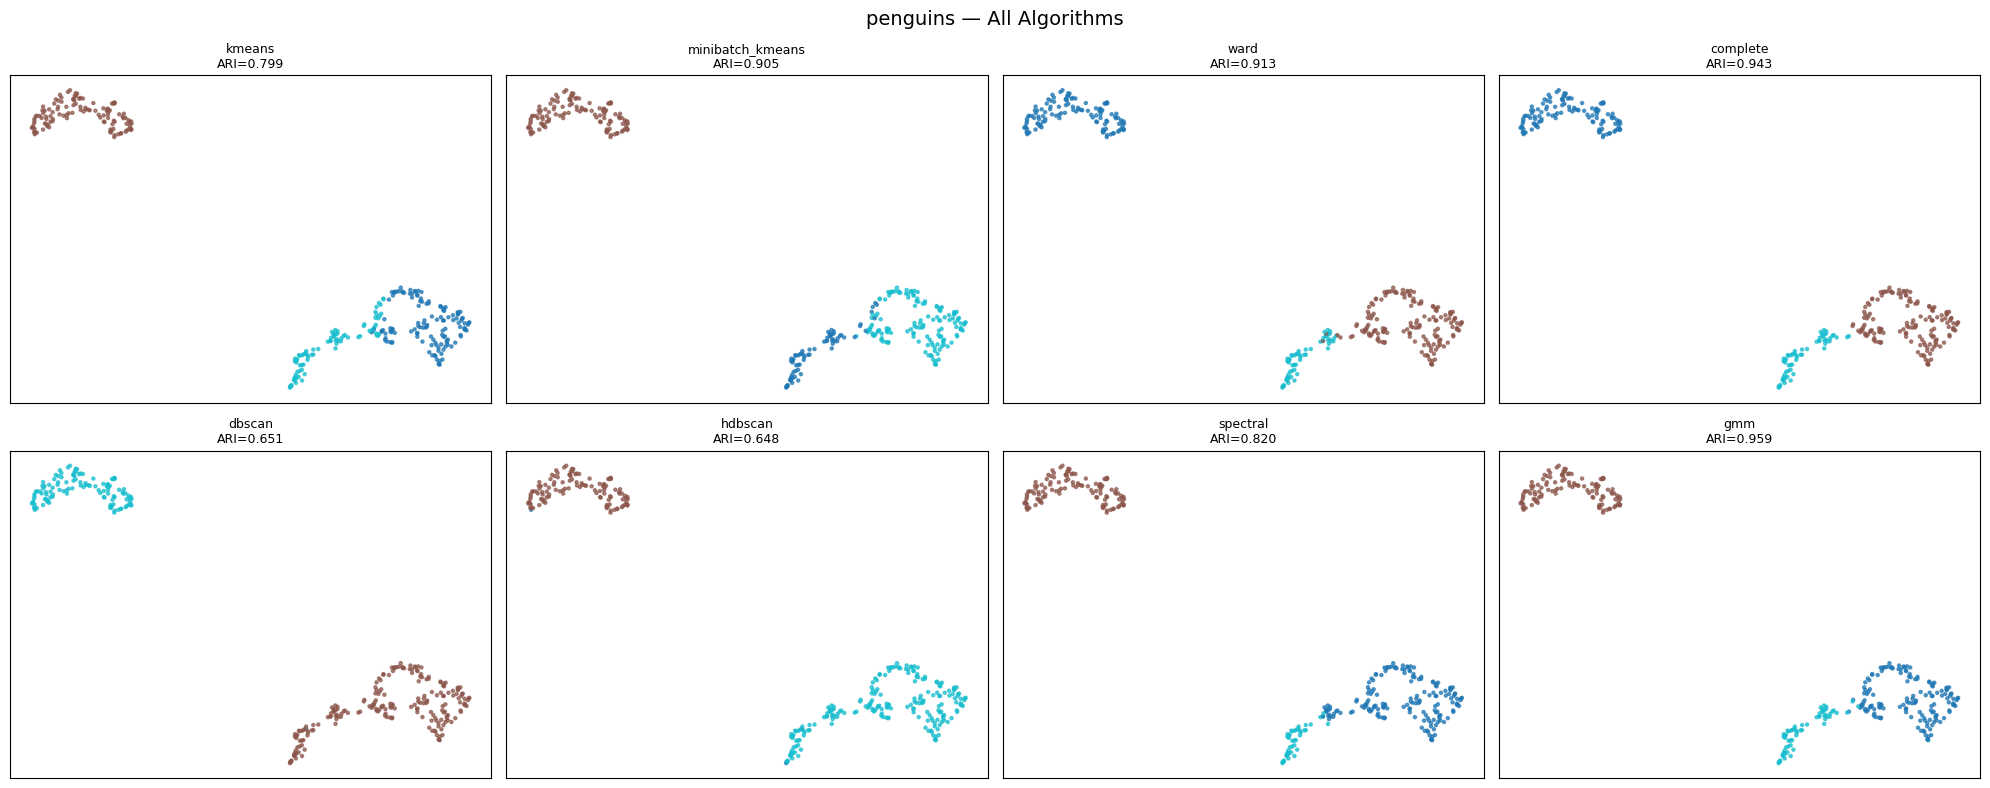

Saved ../outputs/figures/02_umap_penguins.png


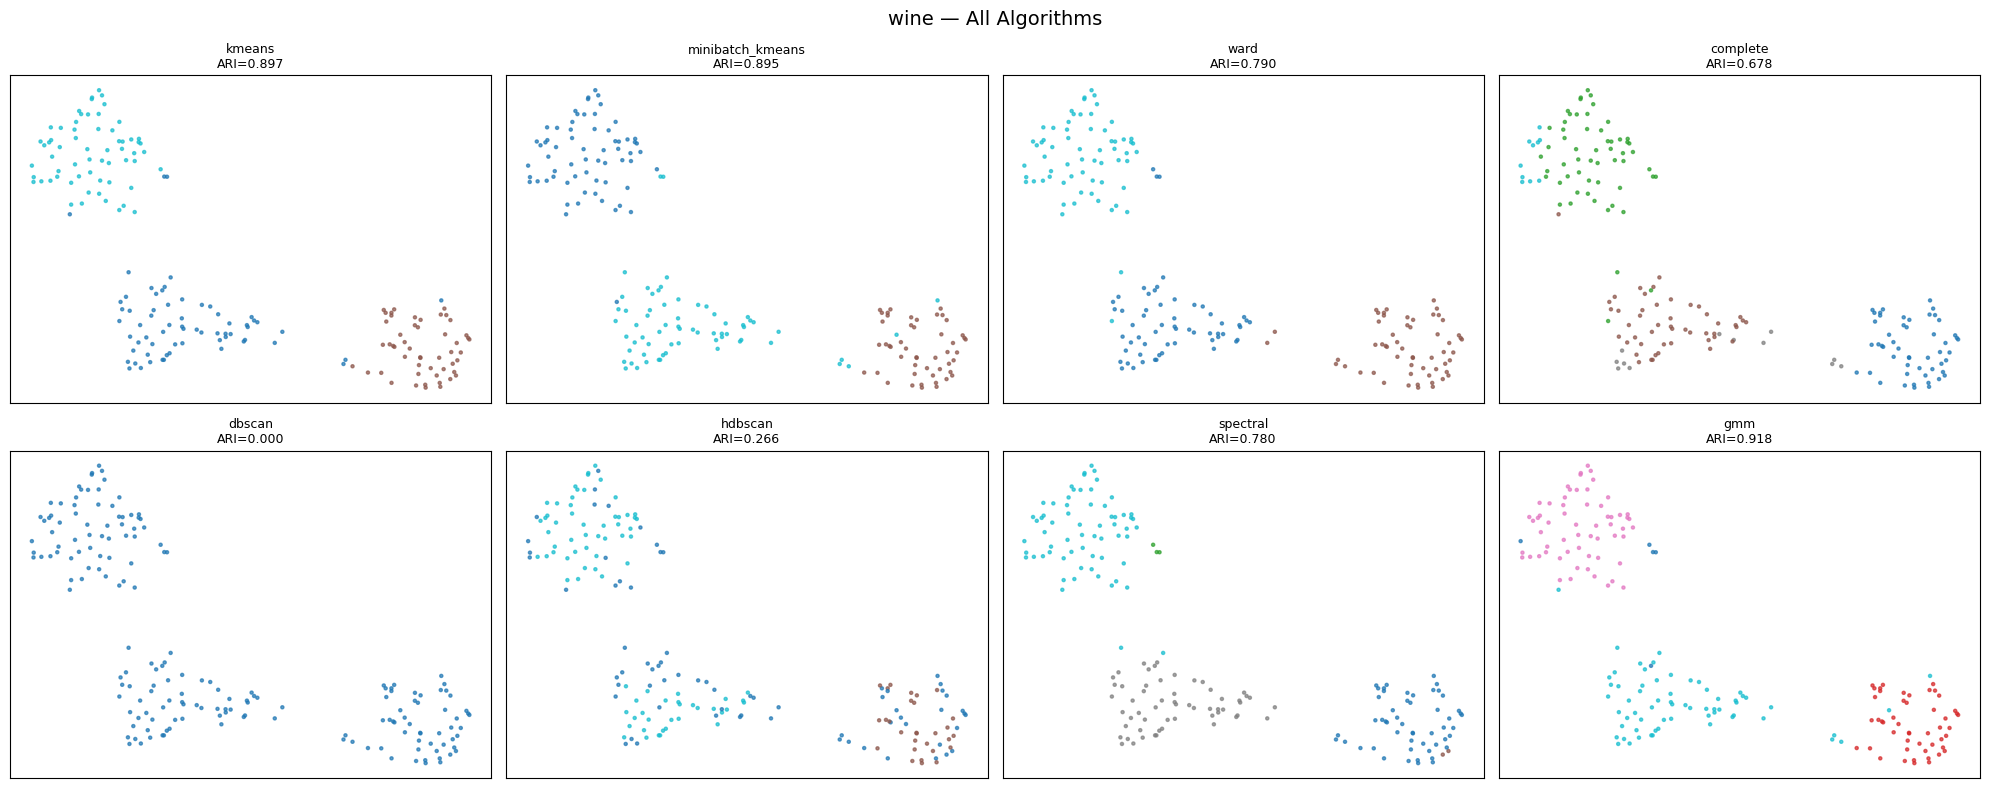

Saved ../outputs/figures/02_umap_wine.png


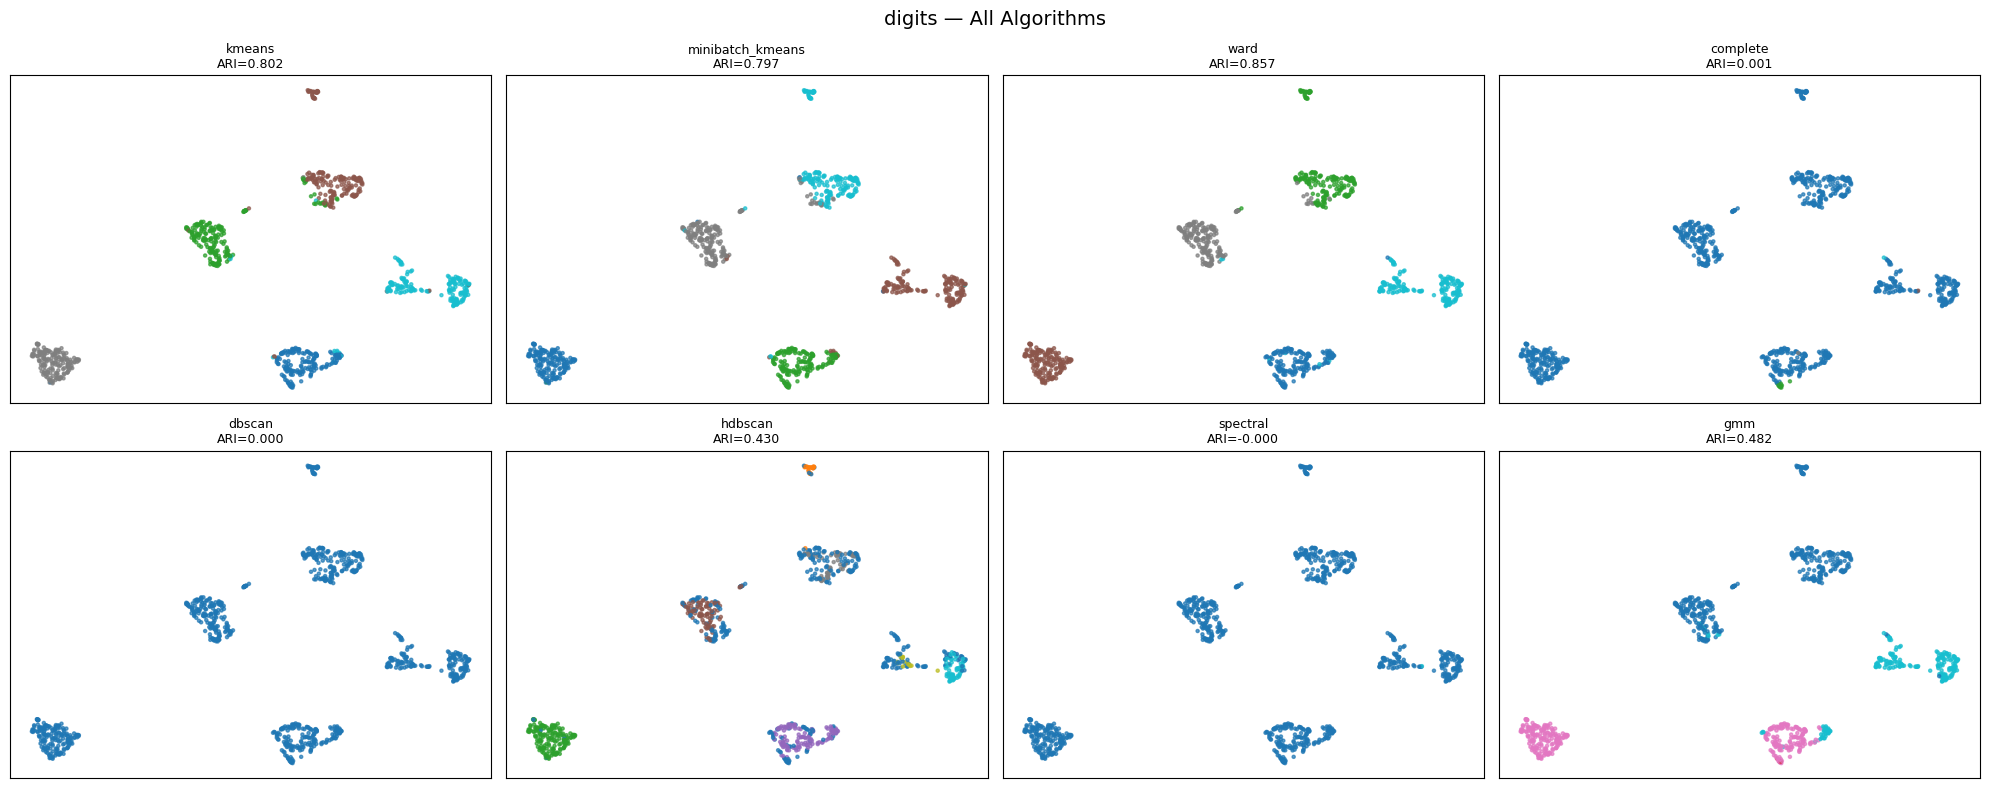

Saved ../outputs/figures/02_umap_digits.png


In [8]:
def get_umap(name, x):
    cache = f'{CACHE_DIR}/umap_{name}.pkl'
    if os.path.exists(cache):
        return joblib.load(cache)
    emb = UMAP(n_neighbors=15, min_dist=0.1, random_state=42, n_jobs=2).fit_transform(x)
    joblib.dump(emb, cache)
    return emb

for ds_name, (x, y) in datasets.items():
    emb = get_umap(ds_name, x)
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    axes = axes.flatten()
    for ax, algo_name in zip(axes, algo_names):
        labels = all_labels[(ds_name, algo_name)]
        ari = results[(results.dataset == ds_name) & (results.algorithm == algo_name)]['ari'].values[0]
        ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap='tab10', s=5, alpha=0.7)
        ax.set_title(f'{algo_name}\nARI={ari:.3f}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f'{ds_name} — All Algorithms', fontsize=14)
    plt.tight_layout()
    out = f'../outputs/figures/02_umap_{ds_name}.png'
    plt.savefig(out, dpi=80, bbox_inches='tight')
    plt.show()
    print(f'Saved {out}')